In [ ]:
import pandas as pd
df = pd.read_csv("insurance.csv")  
df.head()

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


In [2]:
df.info()
df.describe()
df.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   object 
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   object 
 5   region    1338 non-null   object 
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), object(3)
memory usage: 73.3+ KB


age         0
sex         0
bmi         0
children    0
smoker      0
region      0
charges     0
dtype: int64

#### Data Loading
The dataset contains 1338 records with 7 features related to health attributes of individuals. The target variable is `charges` represents insurance premium cost.

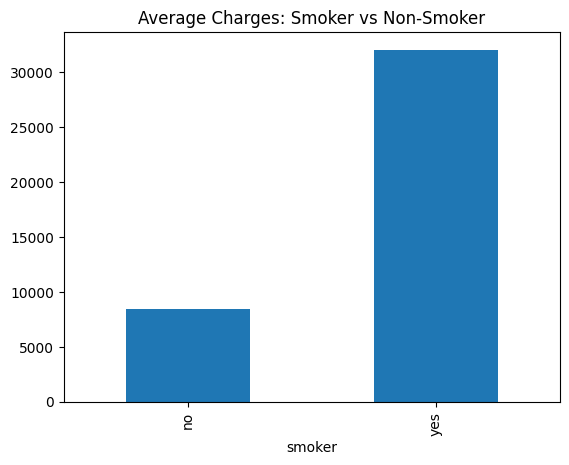

In [ ]:
import matplotlib.pyplot as plt
df.groupby('smoker')['charges'].mean().plot(kind='bar')
plt.title("Average Charges: Smoker vs Non-Smoker")
plt.show()

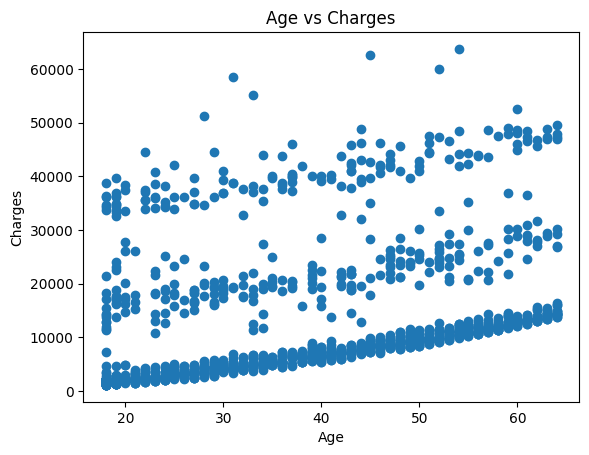

In [4]:
plt.scatter(df['age'], df['charges'])
plt.xlabel("Age")
plt.ylabel("Charges")
plt.title("Age vs Charges")
plt.show()

In [5]:
df_encoded = pd.get_dummies(df, drop_first=True)
df_encoded.head()

,age,bmi,children,charges,sex_male,smoker_yes,region_northwest,region_southeast,region_southwest
0,19,27.900,0,16884.92400,False,True,False,False,True
1,18,33.770,1,1725.55230,True,False,False,True,False
2,28,33.000,3,4449.46200,True,False,False,True,False
3,33,22.705,0,21984.47061,True,False,True,False,False
4,32,28.880,0,3866.85520,True,False,True,False,False


#### Feature Encoding
Categorical variables such as sex, smoker, and region are converted into binary format using encoding.

In [ ]:
df_encoded['age_bmi'] = df_encoded['age'] * df_encoded['bmi']
df_encoded['smoker_bmi'] = df_encoded['smoker_yes'] * df_encoded['bmi']

In [ ]:
import numpy as np

X = df_encoded.drop('charges', axis=1)
y = np.log(df_encoded['charges'])   

#### Feature Selection
The dataset was split into input features (X) and target variable (y). The target variable `charges` was log-transformed to reduce skewness and improve model stability.

In [8]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [9]:
from sklearn.linear_model import LinearRegression

lr_model = LinearRegression()
lr_model.fit(X_train, y_train)

y_pred_lr = lr_model.predict(X_test)

In [10]:
from sklearn.metrics import mean_squared_error, r2_score
import numpy as np

rmse_lr = np.sqrt(mean_squared_error(y_test, y_pred_lr))
r2_lr = r2_score(y_test, y_pred_lr)

print("LR RMSE:", rmse_lr)
print("LR R2:", r2_lr)

LR RMSE: 5796.2846592762735
LR R2: 0.7835929767120723


#### Linear Regression Model
Initially I used Linear Regression as a basic model to understand how the features relate to insurance charges.The performance showed that the relationship is not purely linear.


In [12]:
from sklearn.ensemble import RandomForestRegressor

rf_model = RandomForestRegressor(
    n_estimators=100,
    max_depth=10,
    n_jobs=-1,
    random_state=42)

rf_model.fit(X_train, y_train)

y_pred_rf = rf_model.predict(X_test)

In [13]:
rmse_rf = np.sqrt(mean_squared_error(y_test, y_pred_rf))
r2_rf = r2_score(y_test, y_pred_rf)

print("Random Forest RMSE:", rmse_rf)
print("Random Forest R2:", r2_rf)

Random Forest RMSE: 4568.199228842922
Random Forest R2: 0.8655805816003922


#### Random Forest Model
Then applied  Random Forest model to capture more complex patterns in the data. It performed better than Linear Regression, which indicates that non-linear relationships play an important role.

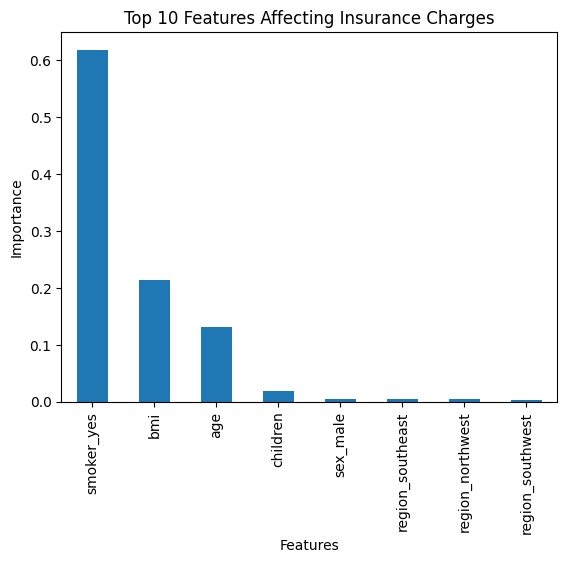

In [16]:
import matplotlib.pyplot as plt

importance = pd.Series(rf_model.feature_importances_, index=X.columns)
importance = importance.sort_values(ascending=False)
importance.head(10).plot(kind='bar')
plt.title("Top 10 Features Affecting Insurance Charges")
plt.xlabel("Features")
plt.ylabel("Importance")
plt.show()

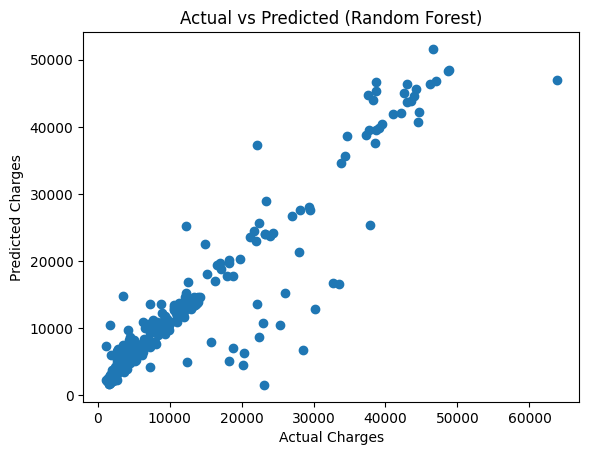

In [17]:
plt.scatter(y_test, y_pred_rf)
plt.xlabel("Actual Charges")
plt.ylabel("Predicted Charges")
plt.title("Actual vs Predicted (Random Forest)")
plt.show()

In [30]:
from sklearn.ensemble import GradientBoostingRegressor

gb_model = GradientBoostingRegressor(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=3,
    random_state=42
)

gb_model.fit(X_train, y_train)

,"loss loss: {'squared_error', 'absolute_error', 'huber', 'quantile'}, default='squared_error'Loss function to be optimized. 'squared_error' refers to the squarederror for regression. 'absolute_error' refers to the absolute error ofregression and is a robust loss function. 'huber' is acombination of the two. 'quantile' allows quantile regression (use`alpha` to specify the quantile).See:ref:`sphx_glr_auto_examples_ensemble_plot_gradient_boosting_quantile.py`for an example that demonstrates quantile regression for creatingprediction intervals with `loss='quantile'`.",'squared_error'
,"learning_rate learning_rate: float, default=0.1Learning rate shrinks the contribution of each tree by `learning_rate`.There is a trade-off between learning_rate and n_estimators.Values must be in the range `[0.0, inf)`.",0.05
,"n_estimators n_estimators: int, default=100The number of boosting stages to perform. Gradient boostingis fairly robust to over-fitting so a large number usuallyresults in better performance.Values must be in the range `[1, inf)`.",300
,"subsample subsample: float, default=1.0The fraction of samples to be used for fitting the individual baselearners. If smaller than 1.0 this results in Stochastic GradientBoosting. `subsample` interacts with the parameter `n_estimators`.Choosing `subsample < 1.0` leads to a reduction of varianceand an increase in bias.Values must be in the range `(0.0, 1.0]`.",1.0
,"criterion criterion: {'friedman_mse', 'squared_error'}, default='friedman_mse'The function to measure the quality of a split. Supported criteria are""friedman_mse"" for the mean squared error with improvement score byFriedman, ""squared_error"" for mean squared error. The default value of""friedman_mse"" is generally the best as it can provide a betterapproximation in some cases... versionadded:: 0.18",'friedman_mse'
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, values must be in the range `[2, inf)`.- If float, values must be in the range `(0.0, 1.0]` and `min_samples_split` will be `ceil(min_samples_split * n_samples)`... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, values must be in the range `[1, inf)`.- If float, values must be in the range `(0.0, 1.0)` and `min_samples_leaf` will be `ceil(min_samples_leaf * n_samples)`... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.Values must be in the range `[0.0, 0.5]`.",0.0
,"max_depth max_depth: int or None, default=3Maximum depth of the individual regression estimators. The maximumdepth limits the number of nodes in the tree. Tune this parameterfor best performance; the best value depends on the interactionof the input variables. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.If int, values must be in the range `[1, inf)`.",3
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.Values must be in the range `[0.0, inf)`.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft

In [36]:
y_pred_gb = gb_model.predict(X_test)

In [21]:
from sklearn.metrics import mean_squared_error, r2_score
import numpy as np

rmse_gb = np.sqrt(mean_squared_error(y_test, y_pred_gb))
r2_gb = r2_score(y_test, y_pred_gb)

print("Gradient Boosting RMSE:", rmse_gb)
print("Gradient Boosting R2:", r2_gb)

Gradient Boosting RMSE: 4329.570010504765
Gradient Boosting R2: 0.8792571359795264


#### Gradient Boosting Model
To improve the results further, I used Gradient Boosting. This model learns from previous errors and gradually improved predictions. It gave the better performance among all the models.


In [22]:
import pandas as pd

results = pd.DataFrame({
    'Model': ['Linear Regression', 'Random Forest', 'Gradient Boosting'],
    'RMSE': [rmse_lr, rmse_rf, rmse_gb],
    'R2 Score': [r2_lr, r2_rf, r2_gb]
})

results

,Model,RMSE,R2 Score
0,Linear Regression,5796.284659,0.783593
1,Random Forest,4568.199229,0.865581
2,Gradient Boosting,4329.570011,0.879257


#### Model Comparison
All the models were compared using RMSE and R² score. Among them, Gradient Boosting performed the best, showing that it is more effective in capturing complex relationships in the dataset.

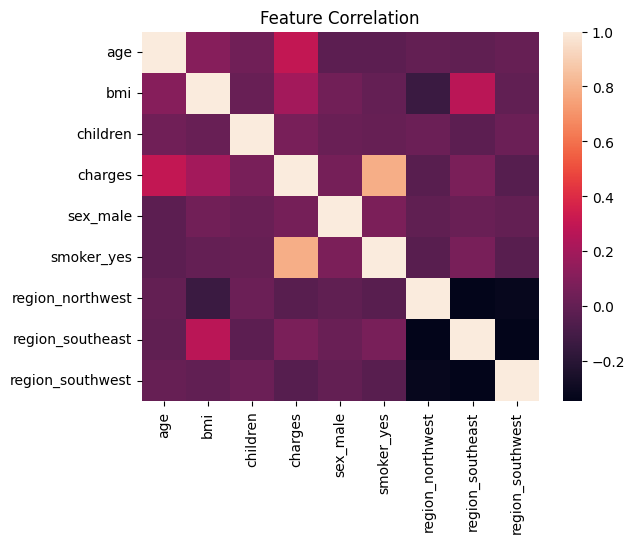

In [24]:
import seaborn as sns

sns.heatmap(df_encoded.corr(), annot=False)
plt.title("Feature Correlation")
plt.show()

#### Final Insights

This project focused on predicting insurance charges using demographic and health-related features. The dataset was clean and well-structured, allowing for smooth preprocessing and model development.

Initial analysis showed that factors such as smoking status, BMI, and age have a strong influence on insurance costs. This was further confirmed through feature importance analysis.

Three models were implemented and compared: Linear Regression, Random Forest, and Gradient Boosting. Linear Regression provided a baseline with an R² score of 0.78 and RMSE of 5796, indicating moderate performance. Random Forest improved the results significantly, achieving an R² score of 0.86 and RMSE of 4568 by capturing non-linear relationships.

Gradient Boosting delivered the best performance among all models. After hyperparameter tuning, it achieved an R² score of approximately 0.88 and RMSE of around 4329, showing better accuracy and reduced prediction error.

Overall, the results demonstrate that insurance pricing is influenced by multiple interacting factors, and advanced ensemble models are more effective in capturing these patterns. The final model can be used to estimate insurance charges and support data-driven decision-making.